# 07. 임계값에 따른 지표 변화

**이 노트북의 목적**

`pro2`(흉부 X선)에서 임계값 0.05~0.95를 훑으며 민감도·특이도·정밀도가 어떻게 움직이는지 봤고,
"민감도 99% 이상을 만족하는 것 중 특이도가 가장 높은 임계값"으로 0.60을 골랐다.

여기서 같은 분석을 12클래스로 옮긴다. 그런데 다중분류는 `argmax`를 쓰기 때문에
"임계값 0.5"라는 게 그대로는 존재하지 않는다. 세 가지 해석이 가능하고 셋 다 해본다.

| 방식 | 무엇을 조정하나 | `pro2` 대응 |
|---|---|---|
| ① OvR 임계값 | 한 클래스를 이진 문제로 보고 그 문턱 | 민감도/특이도 곡선 그대로 |
| ② 클래스별 가중 argmax | 클래스마다 확률에 곱하는 계수 | 클래스별로 문턱을 다르게 |
| ③ 전역 확신도 보류 | "자신 없으면 사람에게" 기준 | 임계값-FN 곡선 |

**`pro2`와 다르게 하는 것 한 가지**

`pro2`는 test 확률에서 임계값을 고르고 그 test 점수를 보고했다. 강의 `3_2`도 같은 방식이었다.
이는 test 정보가 선택에 새어 드는 구조이고, 같은 강의 `4_8`이 스태킹에서 지적한 문제와 같다.

**이 노트북은 val에서 고르고 test에는 한 번만 적용한다.**

**입력**: `06`이 저장한 `probs_{tag}_val.npy`, `probs_{tag}_test.npy` (모델 재실행 없음)

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, confusion_matrix)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

SPLIT_TAG = "v2"

OUT = Path("outputs/garbage")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

val_probs  = np.load(OUT / "metrics" / f"probs_{SPLIT_TAG}_val.npy")
test_probs = np.load(OUT / "metrics" / f"probs_{SPLIT_TAG}_test.npy")
val_rec    = pd.read_csv(OUT / "metrics" / f"preds_{SPLIT_TAG}_val.csv")
test_rec   = pd.read_csv(OUT / "metrics" / f"preds_{SPLIT_TAG}_test.csv")
final      = json.load(open(OUT / "metrics" / f"final_{SPLIT_TAG}.json", encoding="utf-8"))

val_trues  = val_rec["true_idx"].values
test_trues = test_rec["true_idx"].values

print(f"모델 {final['model']} / {final['exp']} ({SPLIT_TAG})")
print(f"val {val_probs.shape} | test {test_probs.shape}")
print(f"기준 성능 (argmax): test accuracy {final['test']['accuracy']:.4f} "
      f"macro-F1 {final['test']['macro_f1']:.4f}")

모델 ResNet18 / finetune (v2)
val (2323, 12) | test (2323, 12)
기준 성능 (argmax): test accuracy 0.9453 macro-F1 0.9182


## 0. 먼저 확인 — 안 바뀌는 조정이 있다

**모든 클래스에 똑같이 적용하는 변환은 예측을 하나도 바꾸지 않는다.** `argmax`는 단조 변환에
불변이기 때문이다. 온도 스케일링(`logits / T`)이 대표적이다. 확신도 숫자는 전부 달라지는데
정확도와 macro-F1은 소수점까지 똑같이 나온다.

예측이 바뀌려면 **클래스마다 다르게** 조정해야 한다. 이진 분류와 결정적으로 다른 지점이라
먼저 직접 확인하고 넘어간다.

In [3]:
def softmax(z, axis=1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


logits_like = np.log(np.clip(test_probs, 1e-12, None))
base_pred = test_probs.argmax(axis=1)

print(f"{'T':>6}{'평균 확신도':>14}{'accuracy':>12}{'macro-F1':>12}{'예측 변화':>12}")
for T in [0.5, 1.0, 2.0, 5.0]:
    p = softmax(logits_like / T)
    pred = p.argmax(axis=1)
    print(f"{T:>6.1f}{p.max(axis=1).mean():>14.4f}"
          f"{accuracy_score(test_trues, pred):>12.4f}"
          f"{f1_score(test_trues, pred, average='macro', zero_division=0):>12.4f}"
          f"{int((pred != base_pred).sum()):>12}")

print("\n온도를 바꿔도 예측은 한 장도 안 바뀝니다. 확신도 숫자만 달라집니다.")

     T        평균 확신도    accuracy    macro-F1       예측 변화
   0.5        0.9757      0.9453      0.9182           0
   1.0        0.9385      0.9453      0.9182           0
   2.0        0.7786      0.9453      0.9182           0
   5.0        0.3339      0.9453      0.9182           0

온도를 바꿔도 예측은 한 장도 안 바뀝니다. 확신도 숫자만 달라집니다.


## 1. 방식 ① — 한 클래스의 OvR 임계값

가장 약한 클래스를 골라 "이게 그 클래스인가 아닌가"라는 이진 문제로 바꾼다. 그러면
`pro2`의 곡선을 그대로 그릴 수 있다.

| `pro2` (폐렴) | 여기 |
|---|---|
| 민감도 = 폐렴을 놓치지 않음 | 재현율 = 해당 클래스를 놓치지 않음 |
| 특이도 = 정상을 오진하지 않음 | 특이도 = 다른 클래스를 그것으로 오인하지 않음 |
| 놓친 환자 수 (FN) | 놓친 장수 (FN) |

In [4]:
per_class = pd.read_csv(OUT / "metrics" / f"per_class_{SPLIT_TAG}.csv")
TARGET_CLASS = per_class.iloc[0]["label"]        # F1이 가장 낮은 클래스
TC = label_map[TARGET_CLASS]

print(f"대상 클래스: {TARGET_CLASS} (idx {TC})")
print(per_class.head(3).to_string(index=False))


def ovr_sweep(probs, trues, cls_idx, thresholds):
    y = (trues == cls_idx).astype(int)
    s = probs[:, cls_idx]
    rows = []
    for t in thresholds:
        p = (s >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
        rows.append({"threshold": round(float(t), 3),
                     "recall": tp / (tp + fn) if (tp + fn) else 0.0,
                     "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
                     "precision": tp / (tp + fp) if (tp + fp) else 0.0,
                     "f1": 2 * tp / (2 * tp + fp + fn) if tp else 0.0,
                     "fn": int(fn), "fp": int(fp)})
    return pd.DataFrame(rows)


ths = np.arange(0.05, 0.96, 0.05)
sweep_val = ovr_sweep(val_probs, val_trues, TC, ths)
print()
print(sweep_val.to_string(index=False))

대상 클래스: plastic (idx 8)
      label  support  precision  recall     f1  share_%
    plastic      129     0.8534  0.7674 0.8082      5.6
white-glass      116     0.8785  0.8103 0.8430      5.0
      metal      114     0.7868  0.9386 0.8560      4.9

 threshold   recall  specificity  precision       f1  fn  fp
      0.05 0.968992     0.958067   0.576037 0.722543   4  92
      0.10 0.937984     0.968551   0.636842 0.758621   8  69
      0.15 0.930233     0.978122   0.714286 0.808081   9  48
      0.20 0.906977     0.984959   0.780000 0.838710  12  33
      0.25 0.899225     0.988149   0.816901 0.856089  13  26
      0.30 0.883721     0.990884   0.850746 0.866920  15  20
      0.35 0.852713     0.993619   0.887097 0.869565  19  14
      0.40 0.821705     0.994531   0.898305 0.858300  23  12
      0.45 0.798450     0.994986   0.903509 0.847737  26  11
      0.50 0.775194     0.996354   0.925926 0.843882  29   8
      0.55 0.744186     0.996354   0.923077 0.824034  33   8
      0.60 0.736434

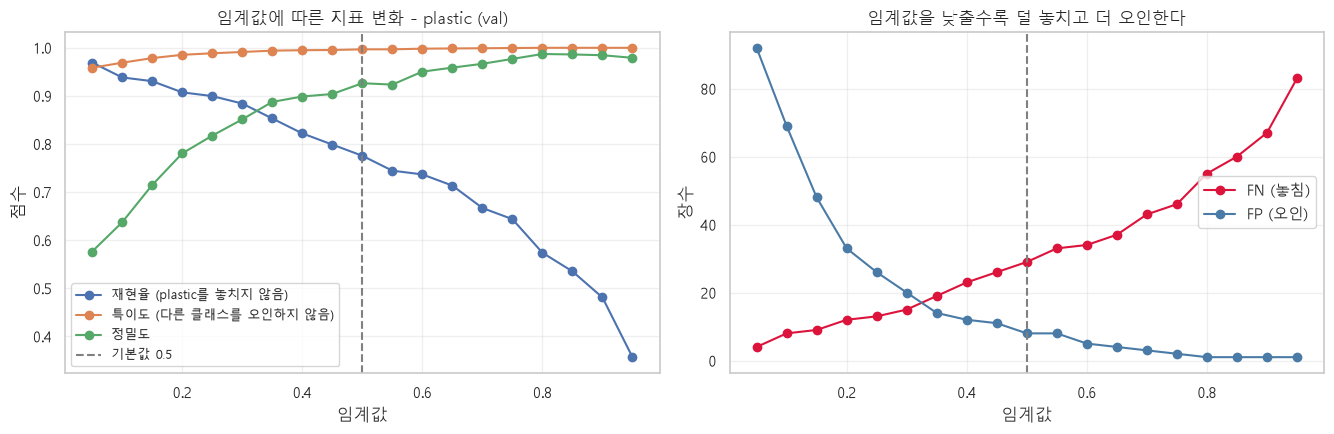

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax = axes[0]
ax.plot(sweep_val["threshold"], sweep_val["recall"], "o-",
        label=f"재현율 ({TARGET_CLASS}를 놓치지 않음)")
ax.plot(sweep_val["threshold"], sweep_val["specificity"], "o-",
        label="특이도 (다른 클래스를 오인하지 않음)")
ax.plot(sweep_val["threshold"], sweep_val["precision"], "o-", label="정밀도")
ax.axvline(0.5, color="gray", ls="--", label="기본값 0.5")
ax.set_xlabel("임계값"); ax.set_ylabel("점수")
ax.set_title(f"임계값에 따른 지표 변화 - {TARGET_CLASS} (val)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep_val["threshold"], sweep_val["fn"], "o-", color="crimson", label="FN (놓침)")
ax.plot(sweep_val["threshold"], sweep_val["fp"], "o-", color="#4a7ba7", label="FP (오인)")
ax.axvline(0.5, color="gray", ls="--")
ax.set_xlabel("임계값"); ax.set_ylabel("장수")
ax.set_title("임계값을 낮출수록 덜 놓치고 더 오인한다")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "figures" / f"16_ovr_threshold_{SPLIT_TAG}.png", dpi=150)
plt.show()

In [6]:
# pro2와 같은 선택 규칙: 목표 재현율을 만족하는 것 중 정밀도가 가장 높은 지점
TARGET_RECALL = 0.95

cands = sweep_val[sweep_val["recall"] >= TARGET_RECALL]
if len(cands):
    chosen = cands.loc[cands["precision"].idxmax()]
    print(f"[val에서 선택] 재현율 {TARGET_RECALL:.0%} 이상 중 정밀도 최대")
    print(f"  임계값 {chosen['threshold']:.2f} -> 재현율 {chosen['recall']:.4f} "
          f"정밀도 {chosen['precision']:.4f} FN {int(chosen['fn'])} FP {int(chosen['fp'])}")

    sweep_test = ovr_sweep(test_probs, test_trues, TC, [chosen["threshold"], 0.5])
    print("\n[test에 한 번만 적용]")
    print(sweep_test.to_string(index=False))
    print("\n위 두 행이 선택한 임계값과 기본값 0.5의 test 성능입니다.")
else:
    print(f"재현율 {TARGET_RECALL:.0%}를 만족하는 임계값이 없습니다. 목표를 낮추세요.")

[val에서 선택] 재현율 95% 이상 중 정밀도 최대
  임계값 0.05 -> 재현율 0.9690 정밀도 0.5760 FN 4 FP 92

[test에 한 번만 적용]
 threshold   recall  specificity  precision       f1  fn  fp
      0.05 0.937984     0.948496   0.517094 0.666667   8 113
      0.50 0.751938     0.993619   0.873874 0.808333  32  14

위 두 행이 선택한 임계값과 기본값 0.5의 test 성능입니다.


## 2. 방식 ② — 클래스별 가중 argmax

OvR은 한 클래스만 본다. 12클래스 전체의 macro-F1을 올리려면 클래스마다 다른 계수를 곱해
`argmax`를 미는 방식이 필요하다.

$$\hat{y} = \arg\max_c \; (w_c \cdot p_c)$$

$w_c$를 클래스 빈도의 역수 계열로 두면 소수 클래스가 이길 확률이 커진다.
지수 $\alpha$ 하나로 세기를 조절한다. $\alpha = 0$이면 기본 `argmax`와 같다.

**이것은 `04`의 `class_weight`·`sampler`와 목적이 같다.** 다만 지점이 다르다.
`04`는 학습 중에 소수 클래스의 비중을 올렸고, 여기서는 학습이 끝난 뒤 결정 단계에서 올린다.

In [7]:
train_counts = (pd.read_csv(OUT / "metrics" / f"class_weights_{SPLIT_TAG}.csv")
                .sort_values("label_idx")["train_count"].values.astype(float))
prior = train_counts / train_counts.sum()


def weighted_argmax(probs, alpha):
    return (probs / (prior ** alpha)).argmax(axis=1)


alphas = np.linspace(0.0, 1.0, 21)
rows = []
for a in alphas:
    pred = weighted_argmax(val_probs, a)
    rows.append({"alpha": round(float(a), 3),
                 "accuracy": accuracy_score(val_trues, pred),
                 "macro_f1": f1_score(val_trues, pred, average="macro", zero_division=0),
                 "macro_recall": recall_score(val_trues, pred, average="macro", zero_division=0),
                 "macro_precision": precision_score(val_trues, pred, average="macro", zero_division=0)})

alpha_df = pd.DataFrame(rows)
best_a = float(alpha_df.loc[alpha_df["macro_f1"].idxmax(), "alpha"])

print(alpha_df.round(4).to_string(index=False))
print(f"\nval macro-F1 최대: alpha = {best_a:.2f}")

 alpha  accuracy  macro_f1  macro_recall  macro_precision
  0.00    0.9539    0.9318        0.9300           0.9357
  0.05    0.9535    0.9316        0.9301           0.9352
  0.10    0.9539    0.9319        0.9307           0.9353
  0.15    0.9544    0.9326        0.9318           0.9356
  0.20    0.9548    0.9330        0.9323           0.9361
  0.25    0.9557    0.9348        0.9346           0.9373
  0.30    0.9557    0.9352        0.9359           0.9367
  0.35    0.9557    0.9350        0.9362           0.9362
  0.40    0.9557    0.9349        0.9366           0.9355
  0.45    0.9552    0.9342        0.9361           0.9347
  0.50    0.9544    0.9334        0.9355           0.9336
  0.55    0.9548    0.9339        0.9362           0.9340
  0.60    0.9544    0.9334        0.9361           0.9333
  0.65    0.9539    0.9332        0.9360           0.9330
  0.70    0.9539    0.9332        0.9360           0.9330
  0.75    0.9535    0.9325        0.9354           0.9322
  0.80    0.95

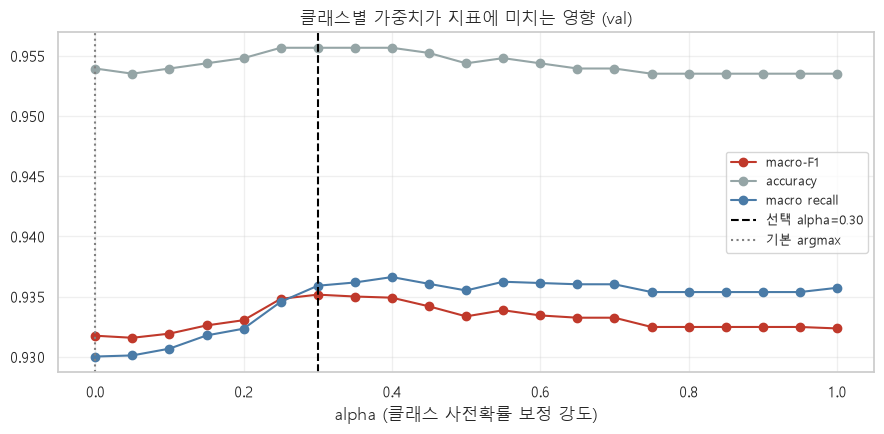

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(alpha_df["alpha"], alpha_df["macro_f1"], "o-", label="macro-F1", color="#c0392b")
ax.plot(alpha_df["alpha"], alpha_df["accuracy"], "o-", label="accuracy", color="#95a5a6")
ax.plot(alpha_df["alpha"], alpha_df["macro_recall"], "o-", label="macro recall", color="#4a7ba7")
ax.axvline(best_a, ls="--", color="black", label=f"선택 alpha={best_a:.2f}")
ax.axvline(0.0, ls=":", color="gray", label="기본 argmax")
ax.set_xlabel("alpha (클래스 사전확률 보정 강도)")
ax.set_title("클래스별 가중치가 지표에 미치는 영향 (val)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "figures" / f"17_alpha_sweep_{SPLIT_TAG}.png", dpi=150)
plt.show()

In [9]:
# val에서 고른 alpha를 test에 한 번만 적용
base_test = test_probs.argmax(axis=1)
adj_test  = weighted_argmax(test_probs, best_a)

rows = []
for name, pred in [("기본 argmax (alpha=0)", base_test),
                   (f"가중 argmax (alpha={best_a:.2f})", adj_test)]:
    rows.append({"방식": name,
                 "accuracy": round(accuracy_score(test_trues, pred), 4),
                 "macro_f1": round(f1_score(test_trues, pred, average="macro", zero_division=0), 4),
                 "macro_recall": round(recall_score(test_trues, pred, average="macro", zero_division=0), 4),
                 "macro_precision": round(precision_score(test_trues, pred, average="macro", zero_division=0), 4)})

adj_cmp = pd.DataFrame(rows)
print(adj_cmp.to_string(index=False))
print(f"\n예측이 바뀐 장수: {int((adj_test != base_test).sum())} / {len(test_trues)}")

f_base = f1_score(test_trues, base_test, average=None, zero_division=0)
f_adj  = f1_score(test_trues, adj_test,  average=None, zero_division=0)
delta = pd.DataFrame({"label": classes,
                      "f1_base": f_base.round(4),
                      "f1_adj": f_adj.round(4),
                      "diff": (f_adj - f_base).round(4)}).sort_values("diff")
print("\n클래스별 변화 (하위 3 / 상위 3)")
print(pd.concat([delta.head(3), delta.tail(3)]).to_string(index=False))

# 08의 McNemar에서 쓸 수 있도록 저장
np.save(OUT / "metrics" / f"pred_base_{SPLIT_TAG}_test.npy", base_test)
np.save(OUT / "metrics" / f"pred_adj_{SPLIT_TAG}_test.npy", adj_test)

                    방식  accuracy  macro_f1  macro_recall  macro_precision
   기본 argmax (alpha=0)    0.9453    0.9182        0.9183           0.9208
가중 argmax (alpha=0.30)    0.9453    0.9177        0.9186           0.9195

예측이 바뀐 장수: 7 / 2323

클래스별 변화 (하위 3 / 상위 3)
      label  f1_base  f1_adj    diff
      metal   0.8560  0.8492 -0.0068
white-glass   0.8430  0.8378 -0.0052
      paper   0.9457  0.9423 -0.0034
    clothes   0.9943  0.9956  0.0013
      shoes   0.9653  0.9669  0.0016
      trash   0.9064  0.9126  0.0062


## 3. 방식 ③ — 전역 확신도 보류

쓰레기 분류의 실제 운영 방식에 가장 가까운 해석이다. `max(softmax) < τ`이면 자동 판정을 포기하고
사람에게 넘긴다. τ를 올리면 자동 처리 비율(커버리지)은 줄지만 자동 처리한 것의 정확도는 올라간다.

`pro2`가 "놓친 환자 수"를 축으로 삼은 것과 같은 구도다. 그쪽은 놓치면 안 되는 것이 폐렴이었고,
여기서는 잘못 분류된 채 자동 처리되는 장수다.

In [10]:
def coverage_curve(probs, trues, thresholds):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    rows = []
    for t in thresholds:
        m = conf >= t
        if m.sum() == 0:
            continue
        rows.append({"tau": round(float(t), 3),
                     "coverage": float(m.mean()),
                     "auto_accuracy": float(accuracy_score(trues[m], pred[m])),
                     "auto_macro_f1": float(f1_score(trues[m], pred[m],
                                                     average="macro", zero_division=0)),
                     "review_n": int((~m).sum()),
                     "auto_errors": int((pred[m] != trues[m]).sum())})
    return pd.DataFrame(rows)


taus = np.arange(0.30, 1.00, 0.02)
cov_val = coverage_curve(val_probs, val_trues, taus)
print(cov_val.iloc[::5].round(4).to_string(index=False))

 tau  coverage  auto_accuracy  auto_macro_f1  review_n  auto_errors
 0.3    0.9991         0.9548         0.9328         2          105
 0.4    0.9927         0.9579         0.9373        17           97
 0.5    0.9802         0.9644         0.9456        46           81
 0.6    0.9557         0.9761         0.9630       103           53
 0.7    0.9264         0.9814         0.9710       171           40
 0.8    0.8954         0.9865         0.9788       243           28
 0.9    0.8476         0.9919         0.9858       354           16


[val에서 선택] 자동 처리 정확도 98% 이상 중 커버리지 최대
  tau = 0.68 | 커버리지 0.933 | 자동 정확도 0.9802 | 사람 검토 155장

[test에 한 번만 적용]
 tau  coverage  auto_accuracy  auto_macro_f1  review_n  auto_errors
0.68    0.9251         0.9786         0.9663       174           46


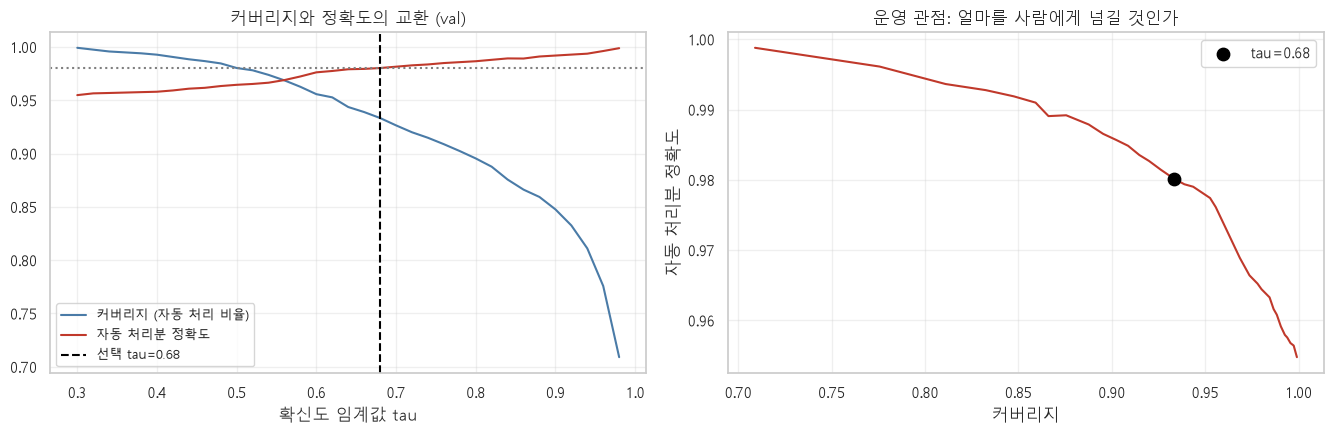

In [11]:
# 선택 규칙: 자동 처리 정확도 목표를 만족하는 것 중 커버리지가 가장 큰 지점
TARGET_AUTO_ACC = 0.98

ok = cov_val[cov_val["auto_accuracy"] >= TARGET_AUTO_ACC]
if len(ok):
    pick = ok.loc[ok["coverage"].idxmax()]
    TAU = float(pick["tau"])
    print(f"[val에서 선택] 자동 처리 정확도 {TARGET_AUTO_ACC:.0%} 이상 중 커버리지 최대")
    print(f"  tau = {TAU:.2f} | 커버리지 {pick['coverage']:.3f} "
          f"| 자동 정확도 {pick['auto_accuracy']:.4f} | 사람 검토 {int(pick['review_n'])}장")
else:
    TAU = 0.90
    print(f"목표 {TARGET_AUTO_ACC:.0%}를 만족하는 tau가 없어 0.90으로 둡니다.")

cov_test = coverage_curve(test_probs, test_trues, [TAU])
print("\n[test에 한 번만 적용]")
print(cov_test.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
ax = axes[0]
ax.plot(cov_val["tau"], cov_val["coverage"], label="커버리지 (자동 처리 비율)", color="#4a7ba7")
ax.plot(cov_val["tau"], cov_val["auto_accuracy"], label="자동 처리분 정확도", color="#c0392b")
ax.axvline(TAU, ls="--", color="black", label=f"선택 tau={TAU:.2f}")
ax.axhline(TARGET_AUTO_ACC, ls=":", color="gray")
ax.set_xlabel("확신도 임계값 tau"); ax.set_title("커버리지와 정확도의 교환 (val)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(cov_val["coverage"], cov_val["auto_accuracy"], "-", color="#c0392b")
ax.scatter([float(cov_val.loc[cov_val.tau.sub(TAU).abs().idxmin(), "coverage"])],
           [float(cov_val.loc[cov_val.tau.sub(TAU).abs().idxmin(), "auto_accuracy"])],
           s=80, zorder=5, color="black", label=f"tau={TAU:.2f}")
ax.set_xlabel("커버리지"); ax.set_ylabel("자동 처리분 정확도")
ax.set_title("운영 관점: 얼마를 사람에게 넘길 것인가")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "figures" / f"18_coverage_{SPLIT_TAG}.png", dpi=150)
plt.show()

In [12]:
threshold_summary = {
    "split_tag": SPLIT_TAG,
    "target_class": TARGET_CLASS,
    "ovr_target_recall": TARGET_RECALL,
    "alpha_best": best_a,
    "alpha_test_macro_f1": float(adj_cmp.iloc[1]["macro_f1"]),
    "alpha_base_macro_f1": float(adj_cmp.iloc[0]["macro_f1"]),
    "tau": TAU,
    "tau_target_auto_acc": TARGET_AUTO_ACC,
    "tau_test_coverage": float(cov_test.iloc[0]["coverage"]),
    "tau_test_auto_accuracy": float(cov_test.iloc[0]["auto_accuracy"]),
    "selected_on": "validation only",
}
with open(OUT / "metrics" / f"threshold_{SPLIT_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(threshold_summary, f, ensure_ascii=False, indent=2)

print(json.dumps(threshold_summary, ensure_ascii=False, indent=2))

{
  "split_tag": "v2",
  "target_class": "plastic",
  "ovr_target_recall": 0.95,
  "alpha_best": 0.3,
  "alpha_test_macro_f1": 0.9177,
  "alpha_base_macro_f1": 0.9182,
  "tau": 0.68,
  "tau_target_auto_acc": 0.98,
  "tau_test_coverage": 0.9250968575118381,
  "tau_test_auto_accuracy": 0.9785946952070731,
  "selected_on": "validation only"
}


## 정리

| 방식 | val에서 고른 값 | 결과 |
|---|---|---|
| ① OvR 임계값 | 목표 재현율 하 정밀도 최대 | 재현율↑ 정밀도↓ 교환 확인 |
| ② 가중 argmax | `alpha` | macro-F1 변화 |
| ③ 확신도 보류 | `tau` | 커버리지-정확도 교환 |

**곡선이 평평하게 나왔다면 그것도 결과다.** `06`의 확신도 분포에서 봤듯 이 모델은 확률이
0과 1에 몰려 있다. 확률이 0.5~0.9 구간에 있는 샘플이 적으면 임계값을 옮겨도 건드려지는 장수가
적어 곡선이 완만해진다.

`pro2`(폐렴)는 임계값을 0.5에서 0.6으로 옮기는 것만으로 특이도가 눈에 띄게 움직였다.
그 모델은 정확도 0.81에 특이도 0.52로 애매한 상태였기 때문이다. **같은 기법이라도 모델의
성능과 확률 보정 상태에 따라 작동 폭이 다르다** — 이것이 두 사례를 나란히 놓고 얻는 결론이다.

**모두 val에서 골랐다.** 선택에 test를 쓰지 않았으므로 위 test 숫자는 편향되지 않았다.

→ `08_Hypothesis.ipynb`